In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Daily_Activity.csv to Daily_Activity.csv


In [ ]:
df = pd.read_csv("Daily_Activity.csv")

In [ ]:
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,user_date
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,1503960366_2016-03-25
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,1503960366_2016-03-26
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,1503960366_2016-03-27
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,1503960366_2016-03-28
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,1503960366_2016-03-29


Initial Data Exploration

The cleaned daily activity dataset contains 1,373 observations across 16 columns and represents 35 unique users. No missing values were identified. Descriptive statistics were reviewed to understand the distribution of activity, distance, sedentary behavior, and calorie variables before conducting further analysis.

In [ ]:
df.shape

(1373, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        1373 non-null   int64  
 1   ActivityDate              1373 non-null   object 
 2   TotalSteps                1373 non-null   int64  
 3   TotalDistance             1373 non-null   float64
 4   TrackerDistance           1373 non-null   float64
 5   LoggedActivitiesDistance  1373 non-null   float64
 6   VeryActiveDistance        1373 non-null   float64
 7   ModeratelyActiveDistance  1373 non-null   float64
 8   LightActiveDistance       1373 non-null   float64
 9   SedentaryActiveDistance   1373 non-null   float64
 10  VeryActiveMinutes         1373 non-null   int64  
 11  FairlyActiveMinutes       1373 non-null   int64  
 12  LightlyActiveMinutes      1373 non-null   int64  
 13  SedentaryMinutes          1373 non-null   int64  
 14  Calories

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique users:", df["Id"].nunique())
print("Missing values:", df.isna().sum().sum())

Rows: 1373
Columns: 16
Unique users: 35
Missing values: 0


In [ ]:
df.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,1.373000e+03,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000
mean,4.782326e+09,7377.375091,5.289031,5.261930,0.128591,1.413146,0.546052,3.238128,0.001733,19.871085,13.603787,188.096140,1001.346686,2294.812090
std,2.381544e+09,5198.133424,3.987341,3.973439,0.695630,2.622729,0.872581,2.104300,0.007800,31.817631,26.581555,113.095058,304.168197,725.526989
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3321.000000,2.280000,2.270000,0.000000,0.000000,0.000000,1.730000,0.000000,0.000000,0.000000,117.000000,734.000000,1820.000000
50%,4.445115e+09,7142.000000,5.030000,5.020000,0.000000,0.120000,0.200000,3.280000,0.000000,2.000000,6.000000,196.000000,1062.000000,2129.000000
75%,6.962181e+09,10645.000000,7.570000,7.570000,0.000000,1.860000,0.780000,4.710000,0.000000,30.000000,18.000000,263.000000,1246.000000,2781.000000
max,8.877689e+09,36019.000000,28.030001,28.030001,6.727057,21.920000,6.480000,12.510000,0.110000,210.000000,660.000000,720.000000,1440.000000,4900.000000


Analysis: Frequency of Very-Low-Activity Days

The SQL analysis identified a substantial difference in the frequency of very-low-activity days between lower- and higher-activity users. Python was used to extend this analysis by examining the distribution of very-low-activity days at the individual-user level and comparing results across activity groups.

In [ ]:
user_low_activity = (
    df.groupby("Id")
      .agg(
          avg_daily_steps=("TotalSteps", "mean"),
          low_activity_days=("TotalSteps", lambda x: (x < 2000).sum()),
          total_days=("TotalSteps", "count")
      )
      .reset_index()
)

user_low_activity["low_activity_pct"] = (
    user_low_activity["low_activity_days"]
    / user_low_activity["total_days"]
    * 100
)

user_low_activity.head()

,Id,avg_daily_steps,low_activity_days,total_days,low_activity_pct
0,1503960366,12174.795918,1,49,2.040816
1,1624580081,5137.408163,13,49,26.530612
2,1644430081,7780.925000,3,40,7.500000
3,1844505072,2944.500000,17,42,40.476190
4,1927972279,1298.714286,28,42,66.666667


In [ ]:
user_low_activity["activity_group"] = np.where(
    user_low_activity["avg_daily_steps"] < 5000,
    "Lower Activity",
    "Higher Activity"
)

user_low_activity.head()

,Id,avg_daily_steps,low_activity_days,total_days,low_activity_pct,activity_group
0,1503960366,12174.795918,1,49,2.040816,Higher Activity
1,1624580081,5137.408163,13,49,26.530612,Higher Activity
2,1644430081,7780.925000,3,40,7.500000,Higher Activity
3,1844505072,2944.500000,17,42,40.476190,Lower Activity
4,1927972279,1298.714286,28,42,66.666667,Lower Activity


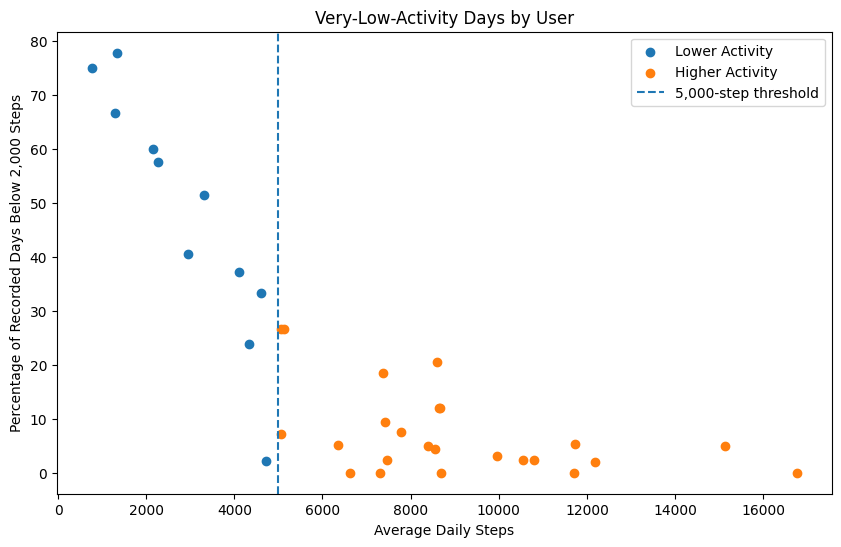

In [ ]:
plt.figure(figsize=(10, 6))

for group in ["Lower Activity", "Higher Activity"]:
    data = user_low_activity[
        user_low_activity["activity_group"] == group
    ]
    plt.scatter(
        data["avg_daily_steps"],
        data["low_activity_pct"],
        label=group
    )

plt.axvline(5000, linestyle="--", label="5,000-step threshold")

plt.xlabel("Average Daily Steps")
plt.ylabel("Percentage of Recorded Days Below 2,000 Steps")
plt.title("Very-Low-Activity Days by User")
plt.legend()
plt.show()

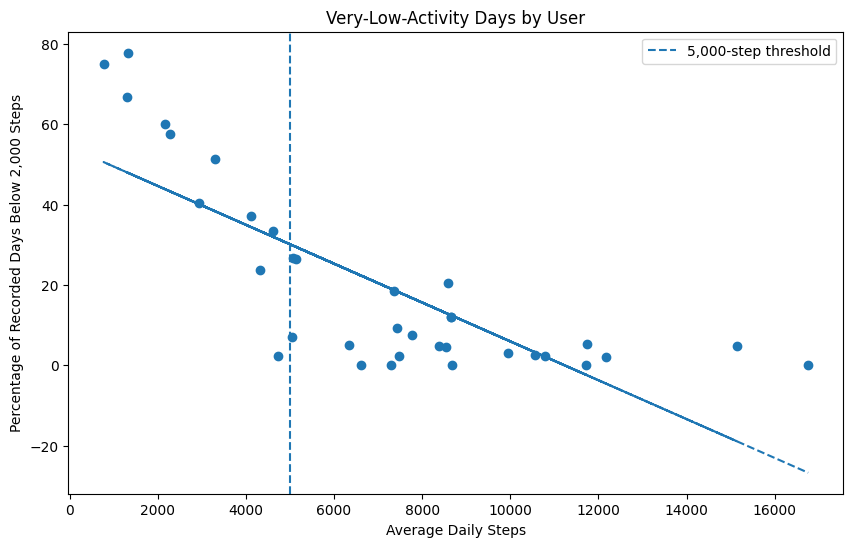

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    user_low_activity["avg_daily_steps"],
    user_low_activity["low_activity_pct"]
)

# Add a linear trendline
z = np.polyfit(
    user_low_activity["avg_daily_steps"],
    user_low_activity["low_activity_pct"],
    1
)
trendline = np.poly1d(z)

plt.plot(
    user_low_activity["avg_daily_steps"],
    trendline(user_low_activity["avg_daily_steps"]),
    linestyle="--"
)

plt.axvline(5000, linestyle="--", label="5,000-step threshold")

plt.xlabel("Average Daily Steps")
plt.ylabel("Percentage of Recorded Days Below 2,000 Steps")
plt.title("Very-Low-Activity Days by User")
plt.legend()
plt.show()

Interpretation

The scatter plot shows a clear inverse pattern between average daily steps and the percentage of recorded days below 2,000 steps. Users with lower average daily steps generally experienced very-low-activity days more frequently, while users with higher average daily steps generally experienced them less frequently. The downward trend supports the SQL finding that very-low-activity days are concentrated among lower-activity users.

In [ ]:
correlation = user_low_activity["avg_daily_steps"].corr(
    user_low_activity["low_activity_pct"]
)

print(f"Correlation: {correlation:.2f}")

Correlation: -0.78


Statistical Result

The correlation between average daily steps and the percentage of recorded days below 2,000 steps was -0.78, indicating a strong negative relationship in this sample. Users with higher average daily steps generally experienced very-low-activity days less frequently. This strengthens the pattern identified in the SQL analysis by showing that the relationship extends beyond the comparison of Lower Activity and Higher Activity group averages.

This analysis is observational and does not establish a causal relationship between daily step levels and the frequency of very-low-activity days.

Conclusion

The Python analysis extended the SQL investigation by examining the relationship at the individual-user level. The strong negative correlation (r = -0.78) and downward trend in the scatter plot reinforce the finding that users with higher average daily activity experienced very-low-activity days less frequently. This provides additional evidence that consistency and reducing periods of very low movement may be useful areas for Bellabeat to address through engagement strategies.